## Glassy California Housing Pricing Case Study

### Premise
For most tabular datasets, many models will perform at the same level as the model with optimal loss. Glassy gives you the tools to apply your domain expertise and judgement to choose among the set of good models.

Some questions Glassy empowers you to answer:
- How much do I value parsimony versus small gains in performance?
- Do good models disagree about which features are important?
- Do good models materially disagree about the same data?
- Can I find a performant model aligning with a subject matter expert's priors?

Glassy allows you to answer these questions for the set of all good models simultaneously, instead of guessing and checking one model at a time.

### Technical design
Glassy is dependency light, only leveraging `numpy` and `scikit-learn`. You can also build its APIs directly from your cleaned data, or apply it off the shelf to the end of an existing sklearn model.

### Current model support
Glassy 0.1.0 focuses only on OLS GLMs. This supports exact mathematical inference on the set of good models. More loss functions for GLMs or classes of models may be added in the future.

*This is the five-minute tour. For a detailed tutorial see `full_tutorial.ipynb`.*

----

In [ ]:
pip install numpy scikit-learn pandas matplotlib glassy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import glassy as gls

Create a base model using standard skl methods

In [3]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
mu, sigma = X_train.mean(), X_train.std()
X_train, X_test = (X_train - mu) / sigma, (X_test - mu) / sigma

model = LinearRegression().fit(X_train, y_train)

Initialize the `Prism` object to explore the set of good models

In [23]:
# Models within 3% of OLS optimal are admitted as "good" models
prism = gls.Prism(model, X_train, y_train, r=3)   

---
### 1. Do good models agree about which features matter?
Checking the range of coefficients in the admissible set is different than classical confidence intervals. 

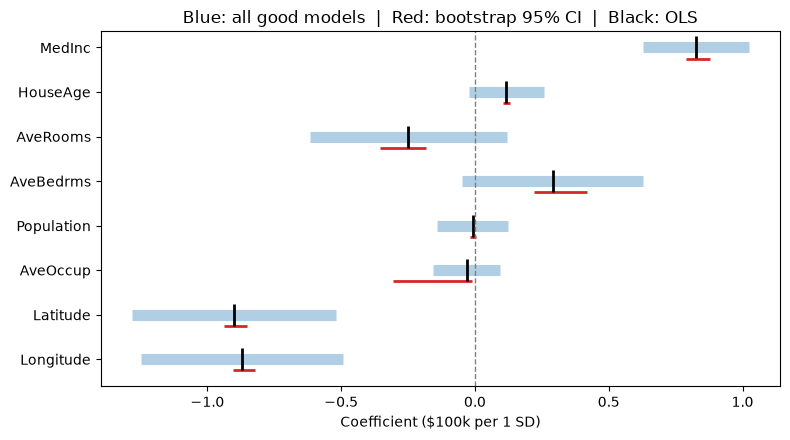

In [24]:
# Classical bootstrapped confidence intervals
rng = np.random.default_rng(0)
boot = []
for _ in range(300):
    i = rng.integers(0, len(X_train), len(X_train))
    boot.append(LinearRegression().fit(X_train.iloc[i], y_train.iloc[i]).coef_)
boot = pd.DataFrame(boot, columns=X_train.columns)

# Glassy approach
bounds = prism.coef_bounds()  # {feature: [min, max]} over all good models
summary = pd.DataFrame(bounds, index=['min', 'max']).T
summary['ols'] = pd.Series(prism.coef_, index=prism.feature_names)


# Plot results 
fig, ax = plt.subplots(figsize=(8, 4.5))
for yv, (feat, row) in zip(np.arange(len(summary))[::-1], summary.iterrows()):
    ax.hlines(yv, row['min'], row['max'], lw=8, alpha=0.35, color='tab:blue')
    ax.hlines(yv - 0.25, boot[feat].quantile(.025), boot[feat].quantile(.975), lw=2, color='tab:red')
    ax.plot(row['ols'], yv, '|', color='k', ms=16, mew=2)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.set_yticks(np.arange(len(summary))[::-1]); ax.set_yticklabels(summary.index)
ax.set_xlabel("Coefficient ($100k per 1 SD)")
ax.set_title("Blue: all good models  |  Red: bootstrap 95% CI  |  Black: OLS")
plt.tight_layout(); plt.show()

**Takeaway:** Glassy reveals how good models disagree about feature usage, which yields different answers than using a confidence interval to check sample noise.

### 2. How much do I value parsimony versus small gains in performance?

In [25]:
# Which features have a good model that excludes them?
droppable_sets = [frozenset(s) for s in prism.droppable(max_terms=None)]
drop = droppable_sets[-1]
droppable_sets

[frozenset({'HouseAge'}),
 frozenset({'AveRooms'}),
 frozenset({'AveBedrms'}),
 frozenset({'Population'}),
 frozenset({'AveOccup'}),
 frozenset({'HouseAge', 'Population'}),
 frozenset({'AveOccup', 'HouseAge'}),
 frozenset({'AveBedrms', 'AveRooms'}),
 frozenset({'AveRooms', 'Population'}),
 frozenset({'AveOccup', 'AveRooms'}),
 frozenset({'AveBedrms', 'Population'}),
 frozenset({'AveBedrms', 'AveOccup'}),
 frozenset({'AveOccup', 'Population'}),
 frozenset({'AveOccup', 'HouseAge', 'Population'}),
 frozenset({'AveBedrms', 'AveRooms', 'Population'}),
 frozenset({'AveBedrms', 'AveOccup', 'AveRooms'}),
 frozenset({'AveOccup', 'AveRooms', 'Population'}),
 frozenset({'AveBedrms', 'AveOccup', 'Population'}),
 frozenset({'AveBedrms', 'AveOccup', 'AveRooms', 'Population'})]

**Takeaway.** Many features can be dropped without leaving the set of good models.

### 3. Do the good models disagree about predictions?
Let's say we wanted to predict which houses have above median prices. How many houses will change status depending on which model in the good set is chosen?

In [26]:
dis = pd.DataFrame(prism.disagreement())              # per-row min / optimal / max prediction (train)
dis_test = pd.DataFrame(prism.disagreement(X_test))   # test

threshold = y_train.median()
def share_straddling(d): 
      return ((d['min'] <= threshold) & (threshold <= d['max'])).mean()

print(f"Median: ${threshold * 100_000:,.0f}")
print(f"% of rows where near-optimal models give opposite results: "
      f"{share_straddling(dis):.1%} (train), {share_straddling(dis_test):.1%} (test)")


Median: $180,250
% of rows where near-optimal models give opposite results: 27.8% (train), 29.3% (test)


**Takeaway.** Which good model you choose can swap policy outcomes for many points in the sample.

### 4. Can I find a performant model that agrees with an expert?
A domain expert on your team believes OLS overweighs the income effect and underweighs longitude location. `from_coef` returns the best-fitting model with that coefficient fixed. We pin it in the lower quarter of the feasible range.

In [27]:
# Grab a good model that aligns to the expert's belief
coef_bounds = prism.coef_bounds(['MedInc', 'Longitude'])
lower_income_coef = coef_bounds['MedInc'][0] + 0.25 * (coef_bounds['MedInc'][1] - coef_bounds['MedInc'][0]) 
higher_long_coef = coef_bounds['Longitude'][1] - 0.25 * (coef_bounds['Longitude'][1] - coef_bounds['Longitude'][0]) 


**Takeaway.** We can easily check if a good model can match our team's judgment (we'll do so below)

### Putting it together
Now we use `Spec`--short for spectrometer--to pull out specific models

In [29]:
# Spec lets you quickly grab interesting models 
spec = gls.Spec(model, X_train, y_train)

In [28]:
lean_model = spec.sans_features(drop)
sme_model = spec.from_coefs({'MedInc': lower_income_coef, 'Longitude': higher_long_coef})

pd.DataFrame({
    'features kept': [8, 8 - len(drop), 8],
    'train MSE': [spec.mse(m, X_train, y_train) for m in (model, lean_model, sme_model)],
    'test MSE': [spec.mse(m, X_test, y_test) for m in (model, lean_model, sme_model)],
    'test loss delta': [spec.mse(m, X_test, y_test) - spec.mse(model, X_test, y_test) for m in (model, lean_model, sme_model)],
    'in good set': [spec.mse(m, X_train, y_train) <= prism.allowed_loss for m in (model, lean_model, sme_model)],
}, index=['Full OLS', 'Parsimonious', 'Expert-aligned']).round(4)

,features kept,train MSE,test MSE,test loss delta,in good set
Full OLS,8,0.5234,0.5290,0.0000,True
Parsimonious,4,0.5377,0.5523,0.0233,True
Expert-aligned,8,0.5360,0.5462,0.0172,True


**Current model class coverage.** Glassy 0.1.0 covers OLS only, which is what makes the answers exact. Other model classes may be added in the future

**Next:** `glassy_learn.ipynb` walks through every method, its options, and its quirks.